<a href="https://colab.research.google.com/github/lelcash/Flower-Detection/blob/main/Flower_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Flower Recognition CNN

This project implements a Convolutional Neural Network (CNN) to automatically identify and classify images of flowers into five distinct categories. It features data augmentation and modular code structure to optimize model accuracy and prevent overfitting.




# Install required packages

In [3]:

!pip install scipy opencv-python kagglehub > /dev/null

import matplotlib.pyplot as plt
import numpy as np
import cv2
import pathlib
import kagglehub
from scipy.signal import convolve2d
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("Setup Complete!")

Setup Complete!


#Data

In [4]:
print("Downloading Flower Dataset...")
download_path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

import os
correct_path = download_path
for root, dirs, files in os.walk(download_path):
    if 'daisy' in dirs and 'rose' in dirs:
        correct_path = root
        break

dataset_path = pathlib.Path(correct_path)
print(f"Dataset securely located at: {dataset_path}")

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Dataset securely located at: /kaggle/input/flowers-recognition/flowers


#Manual convolution

Demonstrating Manual Feature Extraction (Practice 08 Blueprint)


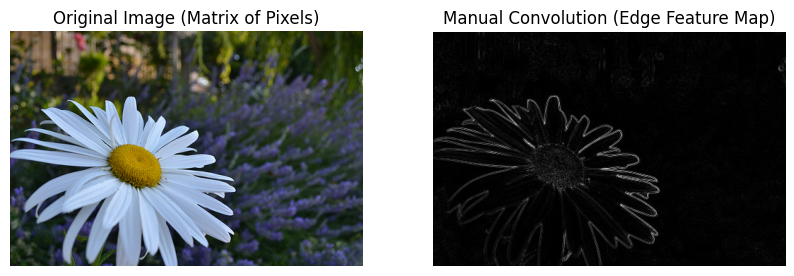

In [5]:
print("Demonstrating Manual Feature Extraction (Practice 08 Blueprint)")

# Grab one random daisy image from our dataset
daisy_path = list(dataset_path.glob('daisy/*.jpg'))[122]
img = cv2.imread(str(daisy_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Laplacian filter
edge_filter = np.array([[-1, -1, -1],
                        [-1,  8, -1],
                        [-1, -1, -1]])

# Apply the manual 2D convolution
convolved_img = convolve2d(gray, edge_filter, mode='valid')

# Plot the comparison
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image (Matrix of Pixels)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.abs(convolved_img), cmap='gray')
plt.title("Manual Convolution (Edge Feature Map)")
plt.axis("off")
plt.show()

#CNN

In [6]:
# AUTOMATED FEATURE EXTRACTION VIA CNN

def load_data(data_dir):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="training", seed=42,
        image_size=(150, 150), batch_size=128)
    val_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, validation_split=0.2, subset="validation", seed=42,
        image_size=(150, 150), batch_size=128)

    AUTOTUNE = tf.data.AUTOTUNE
    return train_ds.cache().prefetch(buffer_size=AUTOTUNE), val_ds.cache().prefetch(buffer_size=AUTOTUNE), train_ds.class_names

train_ds, val_ds, class_names = load_data(dataset_path)

# Build the Model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    layers.Conv2D(32, (5,5), padding='Same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding='Same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=(2,2)),
    layers.Conv2D(96, (3,3), padding='Same', activation='relu'),
    layers.MaxPooling2D((2,2), strides=(2,2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Prevent overfitting
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nTraining the CNN (Automating the convolution process)...")
red_lr = ReduceLROnPlateau(monitor='val_accuracy', patience=3, verbose=1, factor=0.1)
history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[red_lr])

Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training the CNN (Automating the convolution process)...
Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 36s 879ms/step - accuracy: 0.3477 - loss: 1.6041 - val_accuracy: 0.4936 - val_loss: 1.2310 - learning_rate: 0.0010
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.5156 - loss: 1.1877 - val_accuracy: 0.5585 - val_loss: 1.0477 - learning_rate: 0.0010
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.5698 - loss: 1.0750 - val_accuracy: 0.5956 - val_loss: 0.9980 - learning_rate: 0.0010
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.6288 - loss: 0.9661 - val_accuracy: 0.5979 - val_loss: 0.9704 - learning_rate: 0.0010
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.6702 - loss: 0.8841 - val_accuracy: 0.6222 - val_loss: 0.9335 - learning_rate: 0.0010
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.7073 - loss: 0.7924 - val_accuracy: 0.6141 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━

Extracting internal feature maps...
Found Convolutional layer at index 1.


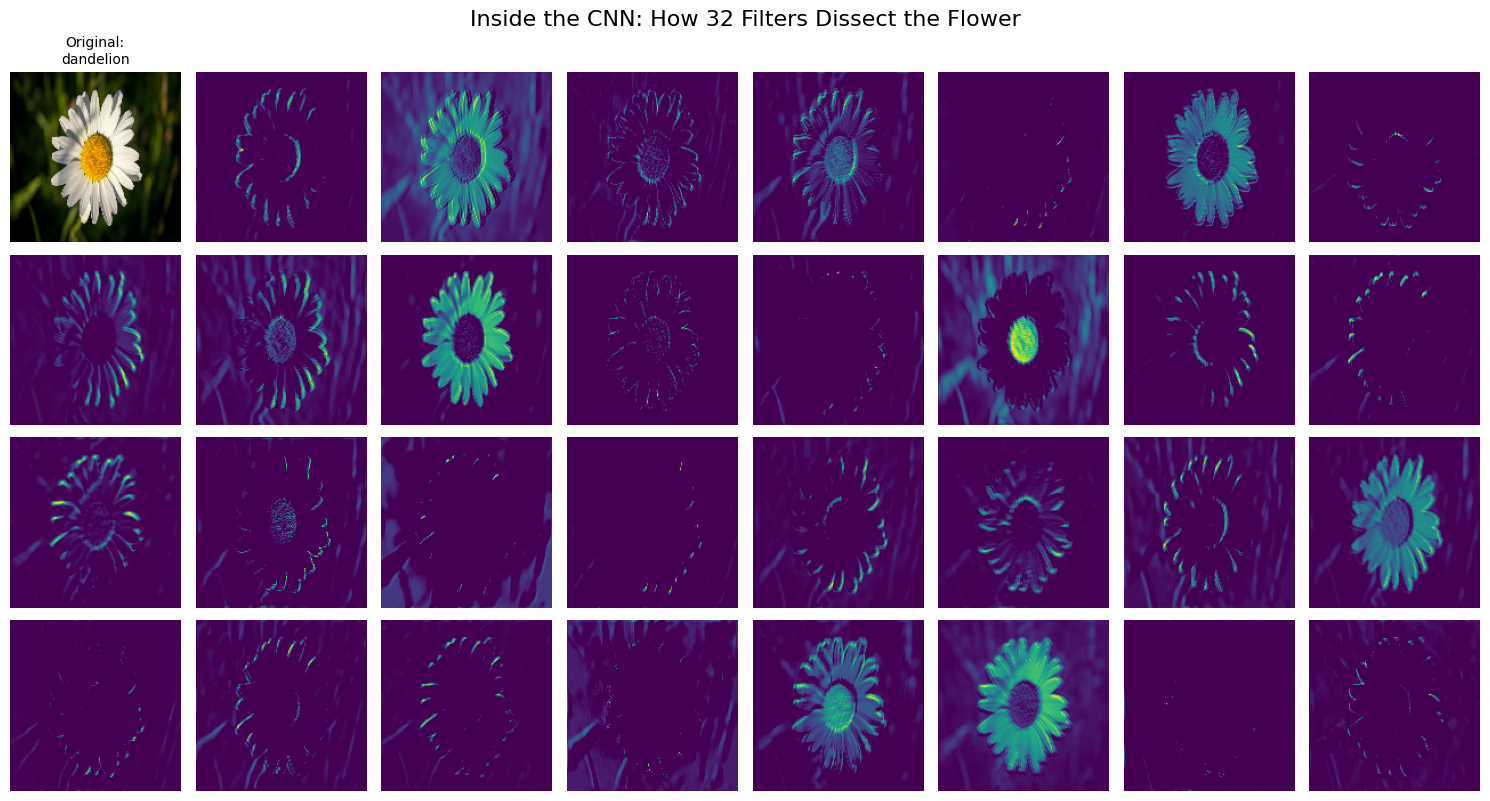

In [7]:
# MODEL INTERPRETABILITY

def visualize_internal_brain(model, val_ds, class_names):
    print("Extracting internal feature maps...")

    # Grab image from the validation set
    for images, labels in val_ds.take(1):
        test_image = images[77]
        true_label = class_names[labels[0].numpy()]
        break

    # Format the image
    img_array = tf.expand_dims(test_image, 0)

    # Find the first Convolutional Layer
    conv_index = 0
    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_index = i
            break

    print(f"Found Convolutional layer at index {conv_index}.")

    # Manually pass the image through the layers
    x = img_array
    for layer in model.layers[:conv_index + 1]:
        x = layer(x, training=False)

    feature_maps = x # The output matrix of the 32 filters

    # Plotting the Results
    plt.figure(figsize=(15, 10))

    # Plot the original image first
    ax = plt.subplot(5, 8, 1)
    plt.imshow(test_image.numpy().astype("uint8"))
    plt.title(f"Original:\n{true_label}", fontsize=10)
    plt.axis("off")

    # Plot the first 31 "Feature Maps"
    for i in range(31):
        ax = plt.subplot(5, 8, i + 2)
        plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
        plt.axis("off")

    plt.suptitle("Inside the CNN: How 32 Filters Dissect the Flower", fontsize=16)
    plt.tight_layout()
    plt.show()

# Execute the visualizer!
visualize_internal_brain(model, val_ds, class_names)

#Better model:

After many trials and research for other models



Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 236ms/step - accuracy: 0.3240 - loss: 1.5099 - val_accuracy: 0.4276 - val_loss: 1.2885 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 162ms/step - accuracy: 0.5142 - loss: 1.1738 - val_accuracy: 0.5272 - val_loss: 1.1010 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.5785 - loss: 1.0645 - val_accuracy: 0.5620 - val_loss: 1.0598 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.6219 - loss: 0.9968 - val_accuracy: 0.5805 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.6277 - loss: 0.9643 - val_accuracy: 0.5979 - val_loss: 1.0000 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 152ms/step - accuracy: 0.6558 - loss: 0.9160 - val_accuracy: 0.6559 - val_loss: 0.9253 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.6621 - loss: 0.8847 

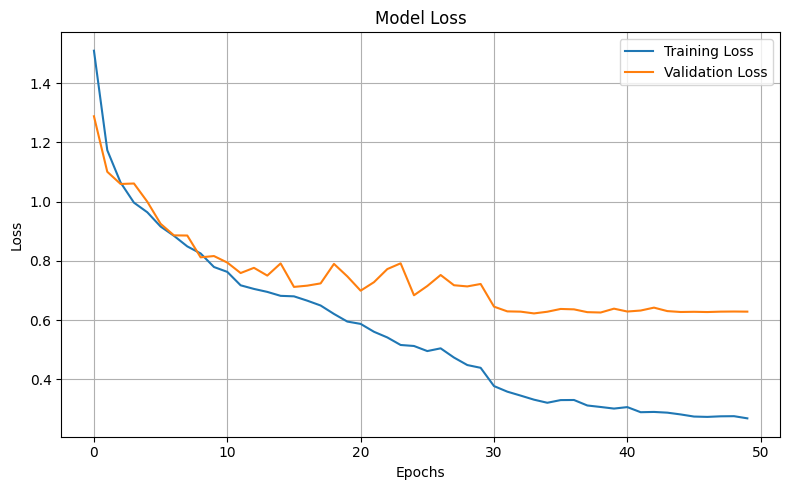

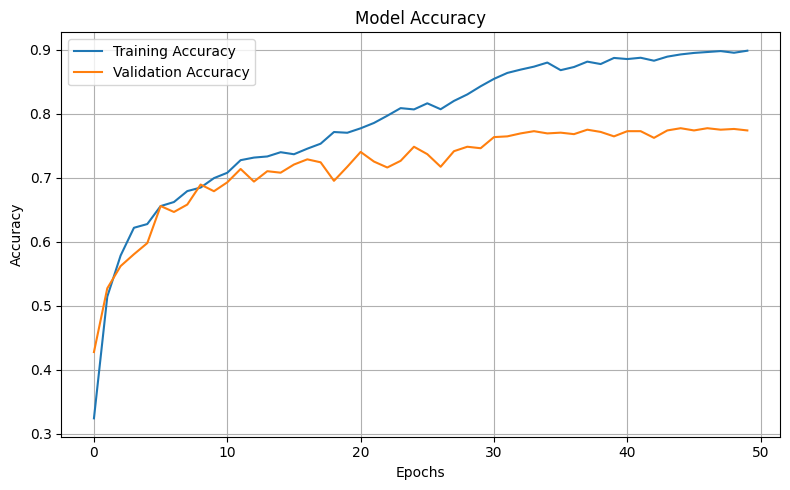

In [8]:
img_height = 150
img_width = 150


def build_cnn_model(img_height, img_width, num_classes):
    model = models.Sequential([
        layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, 5, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(96, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(96, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


model = build_cnn_model(img_height, img_width, len(class_names))


datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

train_ds_aug = train_ds.map(lambda x, y: (tf.image.random_flip_left_right(x), y))


red_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=5,
    verbose=1,
    factor=0.1
)


history = model.fit(
    train_ds_aug,
    validation_data=val_ds,
    epochs=50,
    callbacks=[red_lr]
)


plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Analysis

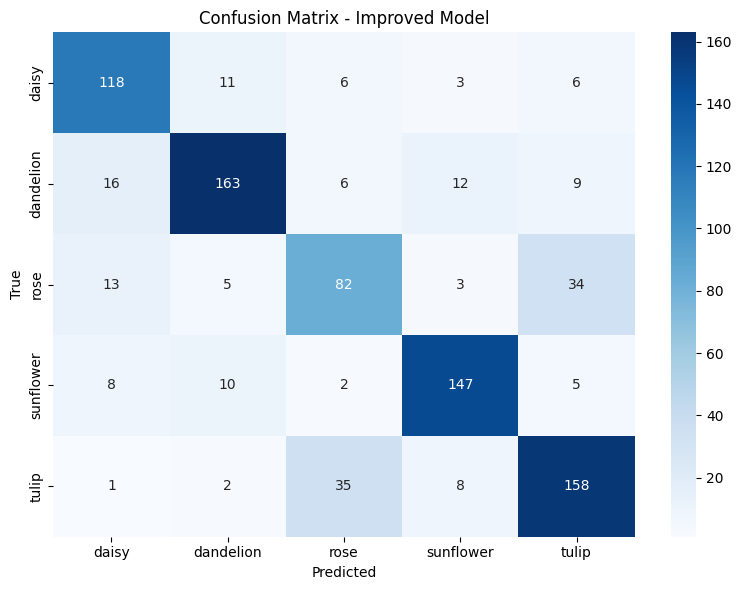

Classification Report:
              precision    recall  f1-score   support

       daisy     0.7564    0.8194    0.7867       144
   dandelion     0.8534    0.7913    0.8212       206
        rose     0.6260    0.5985    0.6119       137
   sunflower     0.8497    0.8547    0.8522       172
       tulip     0.7453    0.7745    0.7596       204

    accuracy                         0.7740       863
   macro avg     0.7662    0.7677    0.7663       863
weighted avg     0.7748    0.7740    0.7738       863

Per-class accuracy:
daisy: 0.8194
dandelion: 0.7913
rose: 0.5985
sunflower: 0.8547
tulip: 0.7745


In [11]:
import seaborn as sns

y_true = []
y_pred = []
y_probs = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Improved Model")
plt.tight_layout()
plt.show()


# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


# Per-class accuracy
print("Per-class accuracy:")
for i, name in enumerate(class_names):
    mask = y_true == i
    acc = np.mean(y_pred[mask] == y_true[mask])
    print(f"{name}: {acc:.4f}")

#Web UI

In [9]:
print("Launching the Flower Recognition Web App...")

import gradio as gr

def predict_flower(image):

    # Preprocess the image to match our model's input shape (150x150)
    img_resized = tf.image.resize(image, (150, 150))

    # Expand dimensions to create a "batch" of 1 (shape: 1, 150, 150, 3)
    img_array = tf.expand_dims(img_resized, 0)

    # Predict using the trained model
    predictions = model.predict(img_array)[0]

    # Format the output as a dictionary for the Gradio labels
    confidence_scores = {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

    return confidence_scores

# Build the User Interface
app = gr.Interface(
    fn=predict_flower,
    inputs=gr.Image(),
    outputs=gr.Label(num_top_classes=3),
    title="CNN Flower Classifier",
    description="Upload a photo of a flower. Our custom Keras CNN will process the image through its convolutional layers and predict if it is a Daisy, Dandelion, Rose, Sunflower, or Tulip.",
    theme="default"
)

app.launch(share=True)

Launching the Flower Recognition Web App...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e7bfbb5fc1f3dd3b0a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
